In [1]:
# ============================================
# WOMEN'S MENTAL HEALTH PROJECT
# Notebook 4: Prevalence vs DALYs Analysis
# Author: Christelle Denny
# Date: June 2026
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load master dataset
master = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/Women's Mental Health/Clean Data/master_dataset.csv")

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries loaded!")
print("✓ Master dataset loaded!")
print(f"Shape: {master.shape}")

✓ Libraries loaded!
✓ Master dataset loaded!
Shape: (1050, 12)


In [2]:
# ============================================
# STEP 1: BASIC STATS — PREVALENCE VS DALYS
# ============================================

print("=== DEPRESSION ===")
print(f"Average Prevalence: {master['depression_rate'].mean():.1f}")
print(f"Average DALYs: {master['depression_daly'].mean():.1f}")
print(f"Correlation: {master['depression_rate'].corr(master['depression_daly']):.3f}")

print("\n=== ANXIETY ===")
print(f"Average Prevalence: {master['anxiety_rate'].mean():.1f}")
print(f"Average DALYs: {master['anxiety_daly'].mean():.1f}")
print(f"Correlation: {master['anxiety_rate'].corr(master['anxiety_daly']):.3f}")

print("\n=== BY INCOME GROUP ===")
income_stats = master.groupby('Income group')[['depression_rate', 'depression_daly', 
                                                'anxiety_rate', 'anxiety_daly']].mean()
print(income_stats.round(1))

=== DEPRESSION ===
Average Prevalence: 5025.8
Average DALYs: 889.1
Correlation: 0.996

=== ANXIETY ===
Average Prevalence: 6611.5
Average DALYs: 786.1
Correlation: 1.000

=== BY INCOME GROUP ===
                     depression_rate  depression_daly  anxiety_rate  \
Income group                                                          
High income                   5215.0            917.7        7758.1   
Low income                    5550.9            983.1        6522.7   
Lower middle income           4809.6            853.7        5265.7   
Upper middle income           4772.8            847.0        6478.1   

                     anxiety_daly  
Income group                       
High income                 923.1  
Low income                  772.1  
Lower middle income         626.3  
Upper middle income         770.5  


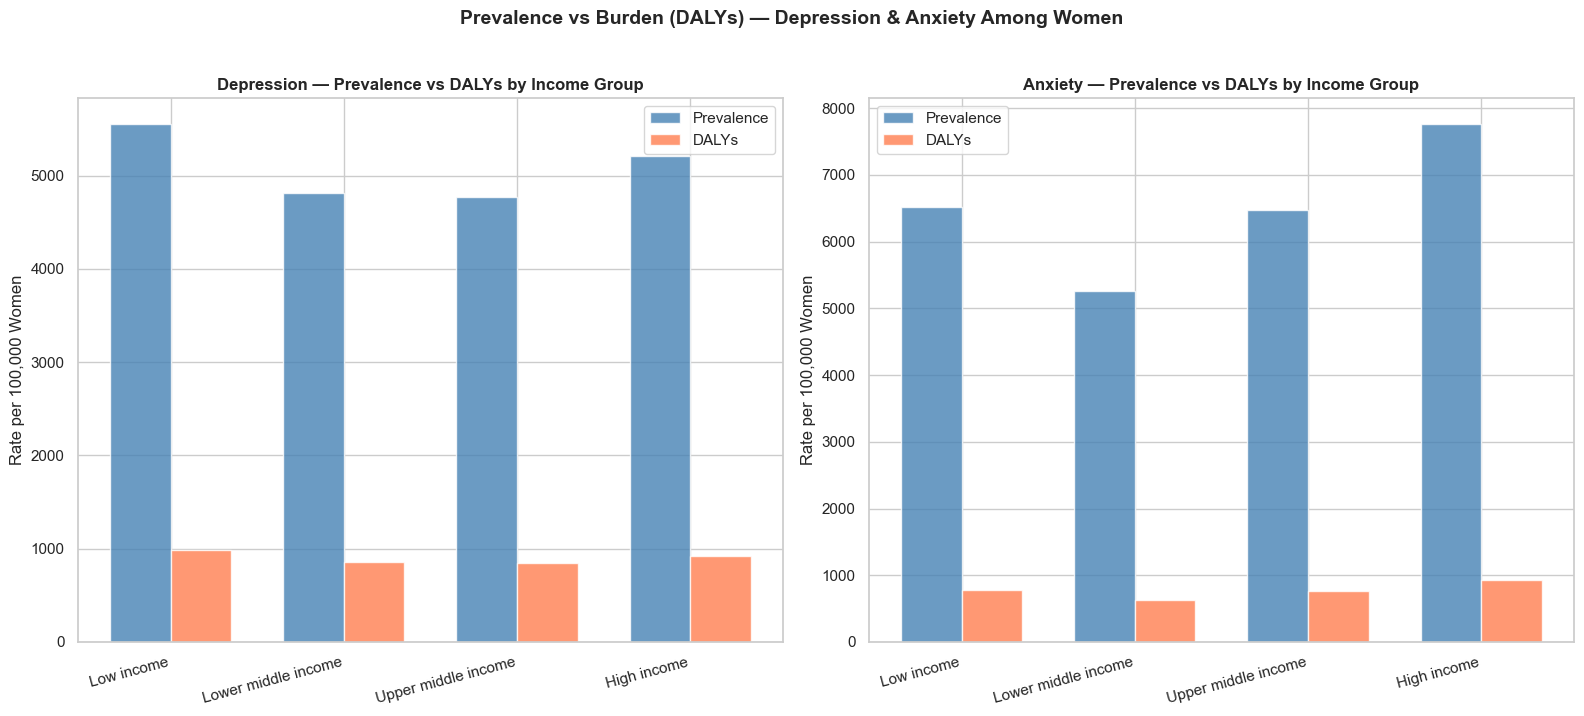

✓ Chart saved!


In [4]:
# ============================================
# STEP 2: PREVALENCE VS DALYS BY INCOME GROUP
# ============================================

income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
income_stats = income_stats.reindex(income_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Depression
x = np.arange(len(income_order))
width = 0.35

axes[0].bar(x - width/2, income_stats['depression_rate'], width, 
            label='Prevalence', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, income_stats['depression_daly'], width,
            label='DALYs', color='coral', alpha=0.8)
axes[0].set_title('Depression — Prevalence vs DALYs by Income Group',
                   fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(income_order, rotation=15, ha='right')
axes[0].set_ylabel('Rate per 100,000 Women')
axes[0].legend()

# Anxiety
axes[1].bar(x - width/2, income_stats['anxiety_rate'], width,
            label='Prevalence', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, income_stats['anxiety_daly'], width,
            label='DALYs', color='coral', alpha=0.8)
axes[1].set_title('Anxiety — Prevalence vs DALYs by Income Group',
                   fontweight='bold', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(income_order, rotation=15, ha='right')
axes[1].set_ylabel('Rate per 100,000 Women')
axes[1].legend()

plt.suptitle('Prevalence vs Burden (DALYs) — Depression & Anxiety Among Women',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("C:/Users/Dell/OneDrive/Desktop/Women's Mental Health/Visualizations/09_prevalence_vs_dalys.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Chart saved!")